In [1]:
### Parte I:

In [2]:
#Importamos paquetes
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Directorio Lucas:

os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\Universidad San Andres\4° Año\Big Data\New folder")

In [4]:
### Ejercicio 1:

# Para este ejercicio, necesitamos traer la base de datos "limpiada" del trabajo práctico anterior. Esto lo hicimos usando .to_parquet para descargar las bases como dta

df = pd.read_parquet("base_con_informal")

In [5]:
df.columns

Index(['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC',
       'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H',
       'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal', 'EMPLEO'],
      dtype='object')

In [6]:
# Recordemos que la variable CH06 encapsula lo referido a las edades de los encuestados. Por lo que la utilizamos para crear "edad2"

df['edad2'] = df['CH06'] ** 2

In [7]:
df.columns

Index(['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC',
       'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H',
       'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal', 'EMPLEO', 'edad2'],
      dtype='object')

In [8]:
# Realicemos los graficos pedidoos

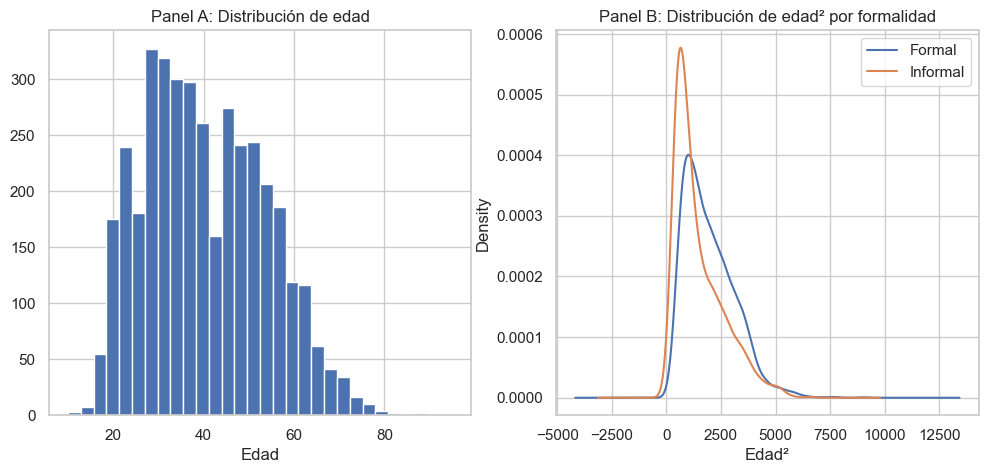

In [9]:
sns.set(style="whitegrid")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Hagamos el histograma para la variable edad

axs[0].hist(df['CH06'].dropna(), bins=30)
axs[0].set_title('Panel A: Distribución de edad')
axs[0].set_xlabel('Edad')

# Ahora construyamos el segundo panel

formales = df[df['informal'] == 0]['edad2'].dropna()
informales = df[df['informal'] == 1]['edad2'].dropna()

formales.plot.kde(ax=axs[1], label='Formal')
informales.plot.kde(ax=axs[1], label='Informal')

axs[1].set_title('Panel B: Distribución de edad² por formalidad')
axs[1].set_xlabel('Edad²')
axs[1].legend()

In [10]:
### Ejercicio 2:

In [11]:
# Empecemos a creear la variable educ, mediante las variables que ya tenemos de las bases de datos previamente guardadas. 
# Para ello usemos for para determinar que se guarda dentro

In [12]:
# Vamos a necesitar traer esas variables dado a que no las tenemos dentro de nuestros dataframes,
# para ello sigamos el mismo proceso que utilizamos en el tp1

df1 = pd.read_excel('usu_individual_T325.xlsx')
df2 = pd.read_stata('individual_t305.dta', convert_categoricals=False)

# Homogeneizamos nombres
df2.columns = df2.columns.str.upper()

# Filtramos región de Cuyo (42) en ambas
df1 = df1[df1["REGION"] == 42]
df2 = df2[df2["REGION"] == 42]

# Agregamos variable de año
df1["AÑO"] = 2025
df2["AÑO"] = 2005

# Convertimos las columnas que están en un formato incorrecto en df2 a numérico
formato_incorrecto = [
    'CH14', 'CH15_COD', 'CH16_COD', 'PP04B_COD', 'PP04D_COD', 'PP11B_COD',
    'PP11D_COD', 'DECOCUR', 'IDECOCUR', 'RDECOCUR', 'GDECOCUR', 'PDECOCUR',
    'ADECOCUR', 'DECINDR', 'IDECINDR', 'RDECINDR', 'GDECINDR', 'PDECINDR',
    'ADECINDR', 'DECIFR', 'IDECIFR', 'RDECIFR', 'GDECIFR', 'PDECIFR',
    'ADECIFR', 'DECCFR', 'IDECCFR', 'RDECCFR', 'GDECCFR', 'PDECCFR', 'ADECCFR'
]

for col in formato_incorrecto:
    if col in df2.columns:
        df2[col] = pd.to_numeric(df2[col], errors='coerce')

# Merge vertical
df_original = pd.concat([df1, df2], ignore_index=True)
df_original2 = df_original.copy()

# Nos quedamos con las variables de interés, incluyendo CH12, CH13 y CH14
columnas_interes = ['AÑO','CH12', 'CH13', 'CH14']

df_original = df_original[columnas_interes]

In [13]:
df_original.head()

,AÑO,CH12,CH13,CH14
0,2025,2.0,2.0,2.0
1,2025,0.0,0.0,NaN
2,2025,2.0,2.0,2.0
3,2025,4.0,1.0,NaN
4,2025,9.0,2.0,98.0


In [14]:
# Creemos ahora la variable educ dentro del dataframe

df_original['educ'] = np.nan

In [15]:
df_original.columns

Index(['AÑO', 'CH12', 'CH13', 'CH14', 'educ'], dtype='object')

In [16]:
# 1) Jardín / preescolar
# Lo más razonable es asignar 0 años de educación formal completa
df_original.loc[df_original['CH12'] == 1, 'educ'] = 0

In [17]:
# 2) Primario incompleto
df_original.loc[(df_original['CH12'] == 2) & (df_original['CH13'] == 2), 'educ'] = df_original['CH14']

# 3) Primario completo
df_original.loc[(df_original['CH12'] == 2) & (df_original['CH13'] == 1), 'educ'] = 6

In [19]:
# 4) EGB
# EGB se puede interpretar como hasta 9 años
df_original.loc[(df_original['CH12'] == 3) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 9)), 'educ'] = df_original['CH14']
df_original.loc[(df_original['CH12'] == 3) & (df_original['CH13'] == 1), 'educ'] = 9

In [20]:
# 5) Secundario incompleto
df_original.loc[(df_original['CH12'] == 3) & (df_original['CH13'] == 2), 'educ'] = 6 + df_original['CH14']

# 6) Secundario completo
df_original.loc[(df_original['CH12'] == 3) & (df_original['CH13'] == 1), 'educ'] = 12

In [21]:
# 7) Polimodal
# Polimodal completo equivale a secundario completo
# como dura 3 años después de EGB, incompleto = 9 + año aprobado
df_original.loc[(df_original['CH12'] == 5) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 3)), 'educ'] = 9 + df_original['CH14']
df_original.loc[(df_original['CH12'] == 5) & (df_original['CH13'] == 1), 'educ'] = 12

In [22]:
# 8) Terciario
# incompleto: 12 + año aprobado
df_original.loc[(df_original['CH12'] == 6) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 9)), 'educ'] = 12 + df_original['CH14']

# completo: asumimos 3 años
df_original.loc[(df_original['CH12'] == 6) & (df_original['CH13'] == 1), 'educ'] = 15

In [23]:
# 8) Universitario
df_original.loc[(df_original['CH12'] == 7) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 9)), 'educ'] = 12 + df_original['CH14']

# completo: asumimos 5 años
df_original.loc[(df_original['CH12'] == 7) & (df_original['CH13'] == 1), 'educ'] = 17


In [24]:
# 9) Posgrado
df_original.loc[(df_original['CH12'] == 8) & (df_original['CH13'] == 2) & (df_original['CH14'].between(0, 9)), 'educ'] = 17 + df_original['CH14']
df_original.loc[(df_original['CH12'] == 8) & (df_original['CH13'] == 1), 'educ'] = 19

In [25]:
# 10) Educación especial -> mejor dejar missing
df_original.loc[df_original['CH12'] == 9, 'educ'] = np.nan

In [26]:
df_original

,AÑO,CH12,CH13,CH14,educ
0,2025,2.0,2.0,2.0,2.0
1,2025,0.0,0.0,NaN,NaN
2,2025,2.0,2.0,2.0,2.0
3,2025,4.0,1.0,NaN,NaN
4,2025,9.0,2.0,98.0,NaN
...,...,...,...,...,...
9259,2005,4.0,2.0,3.0,NaN
9260,2005,3.0,2.0,1.0,7.0
9261,2005,1.0,2.0,0.0,0.0
9262,2005,0.0,0.0,NaN,NaN


In [ ]:
### Ejercicio 3:

In [34]:
# Veamos a la variable que necesitamos actualizar

df_original2['ITF'].describe()

count    9.264000e+03
mean     6.023834e+05
std      1.089384e+06
min      0.000000e+00
25%      5.860000e+02
50%      1.600000e+03
75%      1.000000e+06
max      1.550000e+07
Name: ITF, dtype: float64

In [35]:
# Creemos una variable con el nomnbre que nos pide

df_original2['ingreso_total_familiar'] = df_original2['ITF']

In [38]:
# Necesitamos un factor de inflación para poder actualizar los datos 

factor = 25000

df_original2.loc[df_original2['ANO4'] == 2005, 'ingreso_total_familiar'] *= factor

df_original2['ingreso_total_familiar']

0       1.252000e+06
1       1.252000e+06
2       1.252000e+06
3       1.252000e+06
4       1.252000e+06
            ...     
9259    1.406250e+14
9260    1.406250e+14
9261    1.406250e+14
9262    1.406250e+14
9263    1.406250e+14
Name: ingreso_total_familiar, Length: 9264, dtype: float64

In [ ]:
### Ejercicio 4:

In [40]:
# Creemos la variable pedida para este ejercicio

df_original2['horastrab'] = np.nan

# Necesitamos unicamente sumar para el jefe del hogar, teniendo cuidado de las missing values que podemos tener

df_original2.loc[df_original2['CH03'] == 1, 'horastrab'] = (
    df_original2['PP3E_TOT'].fillna(0) + df_original2['PP3F_TOT'].fillna(0)
)